# Nueva Validación: Algoritmo Genético sobre Datos Sintéticos Nuevos

Este cuaderno ejecuta una **validación externa (out-of-sample)** del sistema de optimización neuroevolutiva. La metodología:

1. **Generación de datos nuevos**: se utiliza el mismo simulador físico de pasteurización (`generar_dataset_pasteurizacion`) con una **semilla diferente** (`seed=2024`), generando un mes completo de operación (30 días).
2. **Optimización por instancia**: para cada registro de producción del mes simulado, se ejecuta el **NSGA-II** con el modelo predictivo MLP entrenado, proponiendo los set-points óptimos $(F_{flow}, T_{servicio})$.
3. **Evaluación comparativa**: se comparan los valores que habría arrojado la planta (datos del simulador) frente a las recomendaciones del sistema IA, cuantificando ahorro energético, eficiencia, producción y seguridad alimentaria.

**Diferencia clave con la evaluación anterior**: los datos de este test **nunca han formado parte** del entrenamiento ni del split de test original (semilla distinta), eliminando cualquier posible sesgo.

> ### 📌 Nota del desarrollador: Validación extra interna
> Este cuaderno es una prueba adicional para validar el algoritmo sobre nuevos datos del simulador. Se ha ejecutado utilizando la arquitectura y configuración de hiperparámetros actualizadas del modelo. 

In [1]:
# ==========================================
# 1. IMPORTACIONES
# ==========================================
import sys
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Asegurar que la raíz del proyecto está en el path
sys.path.insert(0, "../..")

from src.utils.reproducibility import set_seed
from src.utils.constants import FEATURES, TARGETS, BOUNDS, GA_DEFAULT_CONFIG, T_OUT_MIN
from src.utils.paths import PREDICTIONS_DIR, METRICS_DIR, IMAGES_DIR, ensure_dirs
from src.data_processing.simulator import generar_dataset_pasteurizacion
from src.data_processing.preprocessing import filter_production
from src.training.artifacts import load_artifacts
from src.predict.inference import predict_with_model
from src.predict.optimization import (
    setup_nsga2_toolbox,
    run_nsga2_single,
    select_best_from_pareto,
)

ensure_dirs()
print("✅ Importaciones y rutas configuradas.")

✅ Importaciones y rutas configuradas.


## 2. Generación de Datos Sintéticos Nuevos

Se genera un mes completo (30 días) de operación de la planta con `seed=2024`, completamente independiente de los datos usados en entrenamiento/validación/test (`seed=1`).

In [2]:
# ==========================================
# 2. GENERAR DATOS NUEVOS (SEMILLA DIFERENTE)
# ==========================================
VALIDATION_SEED = 2024
VALIDATION_DAYS = 30  # Un mes de operación

df_raw = generar_dataset_pasteurizacion(
    num_dias=VALIDATION_DAYS,
    seed=VALIDATION_SEED,
    save=False,  # No sobreescribir el dataset original
)

# Filtrar solo registros de producción (excluir ciclos CIP)
df_val = filter_production(df_raw).reset_index(drop=True)

print(f"📊 Datos de validación generados (seed={VALIDATION_SEED}, {VALIDATION_DAYS} días)")
print(f"   Registros totales:       {len(df_raw):,}")
print(f"   Registros de producción: {len(df_val):,} (sin CIP)")
print(f"   Ciclos CIP excluidos:    {len(df_raw) - len(df_val):,}")
print(f"\n   Columnas: {list(df_val.columns)}")
display(df_val.describe().round(2))

📊 Datos de validación generados (seed=2024, 30 días)
   Registros totales:       8,640
   Registros de producción: 8,566 (sin CIP)
   Ciclos CIP excluidos:    74

   Columnas: ['Time_min', 'T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P', 'E_consumo', 'T_out_leche', 'Is_Cleaning']


,Time_min,T_in_leche,F_flow,T_servicio,t_ciclo,Delta_P,E_consumo,T_out_leche,Is_Cleaning
count,8566.00,8566.00,8566.00,8566.00,8566.00,8566.00,8566.00,8566.00,8566.0
mean,21595.25,4.00,5001.02,83.44,291.22,0.65,435.76,74.45,0.0
std,12471.70,2.14,99.35,0.82,168.38,0.08,14.26,0.46,0.0
min,0.00,0.05,4632.71,81.01,5.00,0.46,396.11,72.80,0.0
25%,10796.25,1.91,4932.74,82.80,145.00,0.58,424.77,74.13,0.0
50%,21592.50,4.03,5000.77,83.43,290.00,0.64,435.51,74.45,0.0
75%,32393.75,6.11,5068.91,84.07,435.00,0.71,446.88,74.76,0.0
max,43195.00,7.75,5440.21,85.84,670.00,0.88,479.70,75.98,0.0


## 3. Carga de Artefactos del Modelo

Se cargan el modelo MLP, los escaladores y la configuración directamente desde `src.training.artifacts`.

In [3]:
# ==========================================
# 3. CARGAR MODELO Y ESCALADORES
# ==========================================
model, scaler_X, scaler_y, config = load_artifacts()

print(f"✅ Modelo cargado: MLP {config['input_size']} → "
      f"{config['num_layers']}×{config['neurons']} → {config['output_size']}")
print(f"   Features: {config['features_in_order']}")
print(f"   Targets:  {config['targets_in_order']}")
print(f"   Activación: {config['activation']}")

✅ Modelo cargado: MLP 5 → 2×64 → 2
   Features: ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
   Targets:  ['E_consumo', 'T_out_leche']
   Activación: ReLU


## 4. Ejecución del NSGA-II sobre cada Instancia de Validación

Para cada registro de producción del mes simulado:
1. Se fijan las condiciones externas no controlables ($T_{in\_leche}$, $t_{ciclo}$, $\Delta P$).
2. Se ejecuta el NSGA-II completo buscando los set-points óptimos $(F_{flow}, T_{servicio})$.
3. Se selecciona la mejor solución factible del Frente de Pareto (mínimo $E/F$).
4. Se compara con los valores que la planta habría operado (datos del simulador).

In [4]:
# ==============================================================================
# 4. OPTIMIZACIÓN GA SOBRE CADA INSTANCIA DEL MES DE VALIDACIÓN
# ==============================================================================
MASTER_SEED = 100  # Semilla maestra para reproducibilidad del GA
set_seed(MASTER_SEED)

# Configurar toolbox NSGA-II (usa BOUNDS y GA_DEFAULT_CONFIG de constants.py)
toolbox, ga_config = setup_nsga2_toolbox()

resultados = []
n_total = len(df_val)

print(f"🚀 Optimización en tiempo real: {n_total:,} instancias de producción")
print(f"   GA config: pop={ga_config['pop_size']}, λ={ga_config['lambda_']}, "
      f"gen={ga_config['n_gen']}, cxpb={ga_config['cxpb']}, mutpb={ga_config['mutpb']}")
print(f"   Bounds: F_flow ∈ {BOUNDS['F_flow']}, T_servicio ∈ {BOUNDS['T_servicio']}")
print(f"   Restricción: T_out ≥ {T_OUT_MIN}°C")
print("=" * 70)

t_global = time.time()

pbar = tqdm(range(n_total), total=n_total, desc="GA validación final",
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
            unit="inst")

for idx in pbar:
    row = df_val.iloc[idx]
    t_in    = float(row["T_in_leche"])
    dp      = float(row["Delta_P"])
    t_ciclo = float(row["t_ciclo"])

    # Semilla reproducible por instancia
    seed_i = MASTER_SEED + idx

    # Ejecutar NSGA-II para esta instancia
    pop, pareto_front = run_nsga2_single(
        toolbox=toolbox,
        T_in_leche=t_in,
        t_ciclo=t_ciclo,
        Delta_P=dp,
        model=model,
        scaler_X=scaler_X,
        scaler_y=scaler_y,
        ga_config=ga_config,
        seed=seed_i,
    )

    # Seleccionar mejor solución del Frente de Pareto
    best = select_best_from_pareto(
        pareto_front=pareto_front,
        T_in_leche=t_in,
        t_ciclo=t_ciclo,
        Delta_P=dp,
        model=model,
        scaler_X=scaler_X,
        scaler_y=scaler_y,
    )

    resultados.append({
        # Condiciones externas de la instancia
        "T_in_leche": t_in,
        "Delta_P": dp,
        "t_ciclo": t_ciclo,
        # Valores históricos de la planta (simulador)
        "HIST_F_flow": float(row["F_flow"]),
        "HIST_T_servicio": float(row["T_servicio"]),
        "HIST_E_consumo": float(row["E_consumo"]),
        "HIST_T_out": float(row["T_out_leche"]),
        # Recomendación IA (GA)
        "IA_F_flow": round(best["F_flow"], 2),
        "IA_T_servicio": round(best["T_servicio"], 2),
        "IA_E_consumo": round(best["E_consumo"], 4),
        "IA_T_out": round(best["T_out"], 2),
        "IA_consumo_especifico": round(best["specific_consumption"], 6),
        "IA_factible": best["feasible"],
        "n_pareto": best["n_pareto"],
    })

    # Progreso periódico
    if (idx + 1) % 500 == 0:
        pct_fact = sum(1 for r in resultados if r["IA_factible"]) / len(resultados) * 100
        ahorro_parcial = np.mean([r["HIST_E_consumo"] - r["IA_E_consumo"] for r in resultados])
        pbar.set_postfix_str(f"fact={pct_fact:.0f}% | Δ={ahorro_parcial:+.1f}kW")

pbar.close()
t_total = time.time() - t_global

# --- Construir DataFrame de evaluación ---
df_eval = pd.DataFrame(resultados)

# Calcular KPIs comparativos
df_eval["Ahorro_kW"] = df_eval["HIST_E_consumo"] - df_eval["IA_E_consumo"]
df_eval["Ahorro_pct"] = (df_eval["Ahorro_kW"] / df_eval["HIST_E_consumo"]) * 100
df_eval["HIST_Eficiencia"] = df_eval["HIST_E_consumo"] / df_eval["HIST_F_flow"]
df_eval["IA_Eficiencia"] = df_eval["IA_E_consumo"] / df_eval["IA_F_flow"]
df_eval["Mejora_Eficiencia"] = df_eval["HIST_Eficiencia"] - df_eval["IA_Eficiencia"]
df_eval["Delta_F_flow"] = df_eval["IA_F_flow"] - df_eval["HIST_F_flow"]
df_eval["Delta_T_servicio"] = df_eval["IA_T_servicio"] - df_eval["HIST_T_servicio"]

n_factibles = df_eval["IA_factible"].sum()

print("\n" + "=" * 70)
print("✅ OPTIMIZACIÓN COMPLETADA")
print("=" * 70)
print(f"   Instancias procesadas:  {n_total:,}")
print(f"   Soluciones factibles:   {n_factibles:,} ({n_factibles/n_total*100:.1f}%)")
print(f"   Tiempo total:           {t_total:.1f}s ({t_total/60:.1f} min)")
print(f"   Velocidad media:        {n_total/t_total:.1f} inst/s")
print(f"   Ahorro medio:           {df_eval['Ahorro_kW'].mean():+.2f} kW ({df_eval['Ahorro_pct'].mean():+.2f}%)")

🚀 Optimización en tiempo real: 8,566 instancias de producción
   GA config: pop=120, λ=100, gen=15, cxpb=0.9, mutpb=0.1
   Bounds: F_flow ∈ (3500.0, 5500.0), T_servicio ∈ (76.0, 95.0)
   Restricción: T_out ≥ 72.3°C (incluye margen PT100/PMO-FDA)


GA validación final:   0%|          | 0/8566 [00:00<?, ?inst/s]


✅ OPTIMIZACIÓN COMPLETADA
   Instancias procesadas:  8,566
   Soluciones factibles:   8,566 (100.0%)
   Tiempo total:           6342.5s (105.7 min)
   Velocidad media:        1.4 inst/s
   Ahorro medio:           -14.38 kW (-3.36%)


## 5. Cuantificación de KPIs: Planta vs IA Neuroevolutiva

Comparación exhaustiva entre los valores que habría operado la planta (simulador con PID) y las recomendaciones del sistema IA (MLP + NSGA-II).

| KPI | Fórmula | Unidades |
|-----|---------|----------|
| Ahorro energético medio | $\bar{\Delta E} = \bar{E}_{hist} - \bar{E}_{IA}$ | kW |
| Ahorro porcentual | $\frac{\Delta E}{E_{hist}} \times 100$ | % |
| Mejora eficiencia específica | $\frac{E_{hist}}{F_{hist}} - \frac{E_{IA}}{F_{IA}}$ | kW/(L/h) |
| Cumplimiento seguridad | $P(T_{out} \geq 72.3°C)$ | % |

In [5]:
# ==========================================
# 5. TABLA DE KPIs PRINCIPALES
# ==========================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# --- KPIs Energéticos ---
ahorro_medio_kw = df_eval["Ahorro_kW"].mean()
ahorro_total_kw = df_eval["Ahorro_kW"].sum()
ahorro_medio_pct = df_eval["Ahorro_pct"].mean()
E_hist_media = df_eval["HIST_E_consumo"].mean()
E_ia_media = df_eval["IA_E_consumo"].mean()

# --- KPIs de Eficiencia Específica ---
eff_hist_media = df_eval["HIST_Eficiencia"].mean()
eff_ia_media = df_eval["IA_Eficiencia"].mean()
mejora_eff_media = df_eval["Mejora_Eficiencia"].mean()
mejora_eff_pct = (mejora_eff_media / eff_hist_media) * 100

# --- KPIs de Producción ---
F_hist_media = df_eval["HIST_F_flow"].mean()
F_ia_media = df_eval["IA_F_flow"].mean()
delta_F_medio = df_eval["Delta_F_flow"].mean()
delta_F_pct = (delta_F_medio / F_hist_media) * 100

# --- KPIs de Seguridad Alimentaria ---
cumplimiento_hist = (df_eval["HIST_T_out"] >= T_OUT_MIN).mean() * 100
cumplimiento_ia = (df_eval["IA_T_out"] >= T_OUT_MIN).mean() * 100
T_out_ia_min = df_eval["IA_T_out"].min()
T_out_ia_media = df_eval["IA_T_out"].mean()

# --- KPIs de T_servicio ---
T_serv_hist_media = df_eval["HIST_T_servicio"].mean()
T_serv_ia_media = df_eval["IA_T_servicio"].mean()
delta_T_serv = df_eval["Delta_T_servicio"].mean()

print("=" * 70)
print("📊 CUADRO DE MANDO: PLANTA (SIMULADOR) vs IA NEUROEVOLUTIVA")
print(f"   Validación externa — seed={VALIDATION_SEED}, {VALIDATION_DAYS} días")
print("=" * 70)

print(f"\n⚡ ENERGÍA")
print(f"   {'Métrica':<35} {'Planta':>12} {'IA':>12} {'Delta':>12}")
print(f"   {'-'*35} {'-'*12} {'-'*12} {'-'*12}")
print(f"   {'E_consumo medio (kW)':<35} {E_hist_media:>12.2f} {E_ia_media:>12.2f} {ahorro_medio_kw:>+12.2f}")
print(f"   {'Ahorro porcentual (%)':<35} {'':>12} {'':>12} {ahorro_medio_pct:>+12.2f}%")
print(f"   {'Ahorro total acumulado (kW)':<35} {'':>12} {'':>12} {ahorro_total_kw:>+12.1f}")

print(f"\n📈 EFICIENCIA ESPECÍFICA (kW/(L/h))")
print(f"   {'E/F medio':<35} {eff_hist_media:>12.6f} {eff_ia_media:>12.6f} {mejora_eff_media:>+12.6f}")
print(f"   {'Mejora eficiencia (%)':<35} {'':>12} {'':>12} {mejora_eff_pct:>+12.2f}%")

print(f"\n🏭 PRODUCCIÓN (L/h)")
print(f"   {'F_flow medio':<35} {F_hist_media:>12.1f} {F_ia_media:>12.1f} {delta_F_medio:>+12.1f}")
print(f"   {'Cambio producción (%)':<35} {'':>12} {'':>12} {delta_F_pct:>+12.2f}%")

print(f"\n🌡️ TEMPERATURA DE SERVICIO (°C)")
print(f"   {'T_servicio medio':<35} {T_serv_hist_media:>12.2f} {T_serv_ia_media:>12.2f} {delta_T_serv:>+12.2f}")

print(f"\n🔒 SEGURIDAD ALIMENTARIA (T_out ≥ {T_OUT_MIN}°C)")
print(f"   {'Cumplimiento planta':<35} {cumplimiento_hist:>12.1f}%")
print(f"   {'Cumplimiento IA':<35} {cumplimiento_ia:>12.1f}%")
print(f"   {'T_out IA mínimo':<35} {T_out_ia_min:>12.2f} °C")
print(f"   {'T_out IA medio':<35} {T_out_ia_media:>12.2f} °C")
print("=" * 70)

📊 CUADRO DE MANDO: PLANTA (SIMULADOR) vs IA NEUROEVOLUTIVA
   Validación externa — seed=2024, 30 días

⚡ ENERGÍA
   Métrica                                   Planta           IA        Delta
   ----------------------------------- ------------ ------------ ------------
   E_consumo medio (kW)                      435.76       450.15       -14.38
   Ahorro porcentual (%)                                                -3.36%
   Ahorro total acumulado (kW)                                      -123218.1

📈 EFICIENCIA ESPECÍFICA (kW/(L/h))
   E/F medio                               0.087138     0.082023    +0.005115
   Mejora eficiencia (%)                                                +5.87%

🏭 PRODUCCIÓN (L/h)
   F_flow medio                              5001.0       5487.9       +486.9
   Cambio producción (%)                                                +9.74%

🌡️ TEMPERATURA DE SERVICIO (°C)
   T_servicio medio                           83.44        79.80        -3.64

🔒 SEGURIDAD AL

## 6. Visualizaciones Comparativas

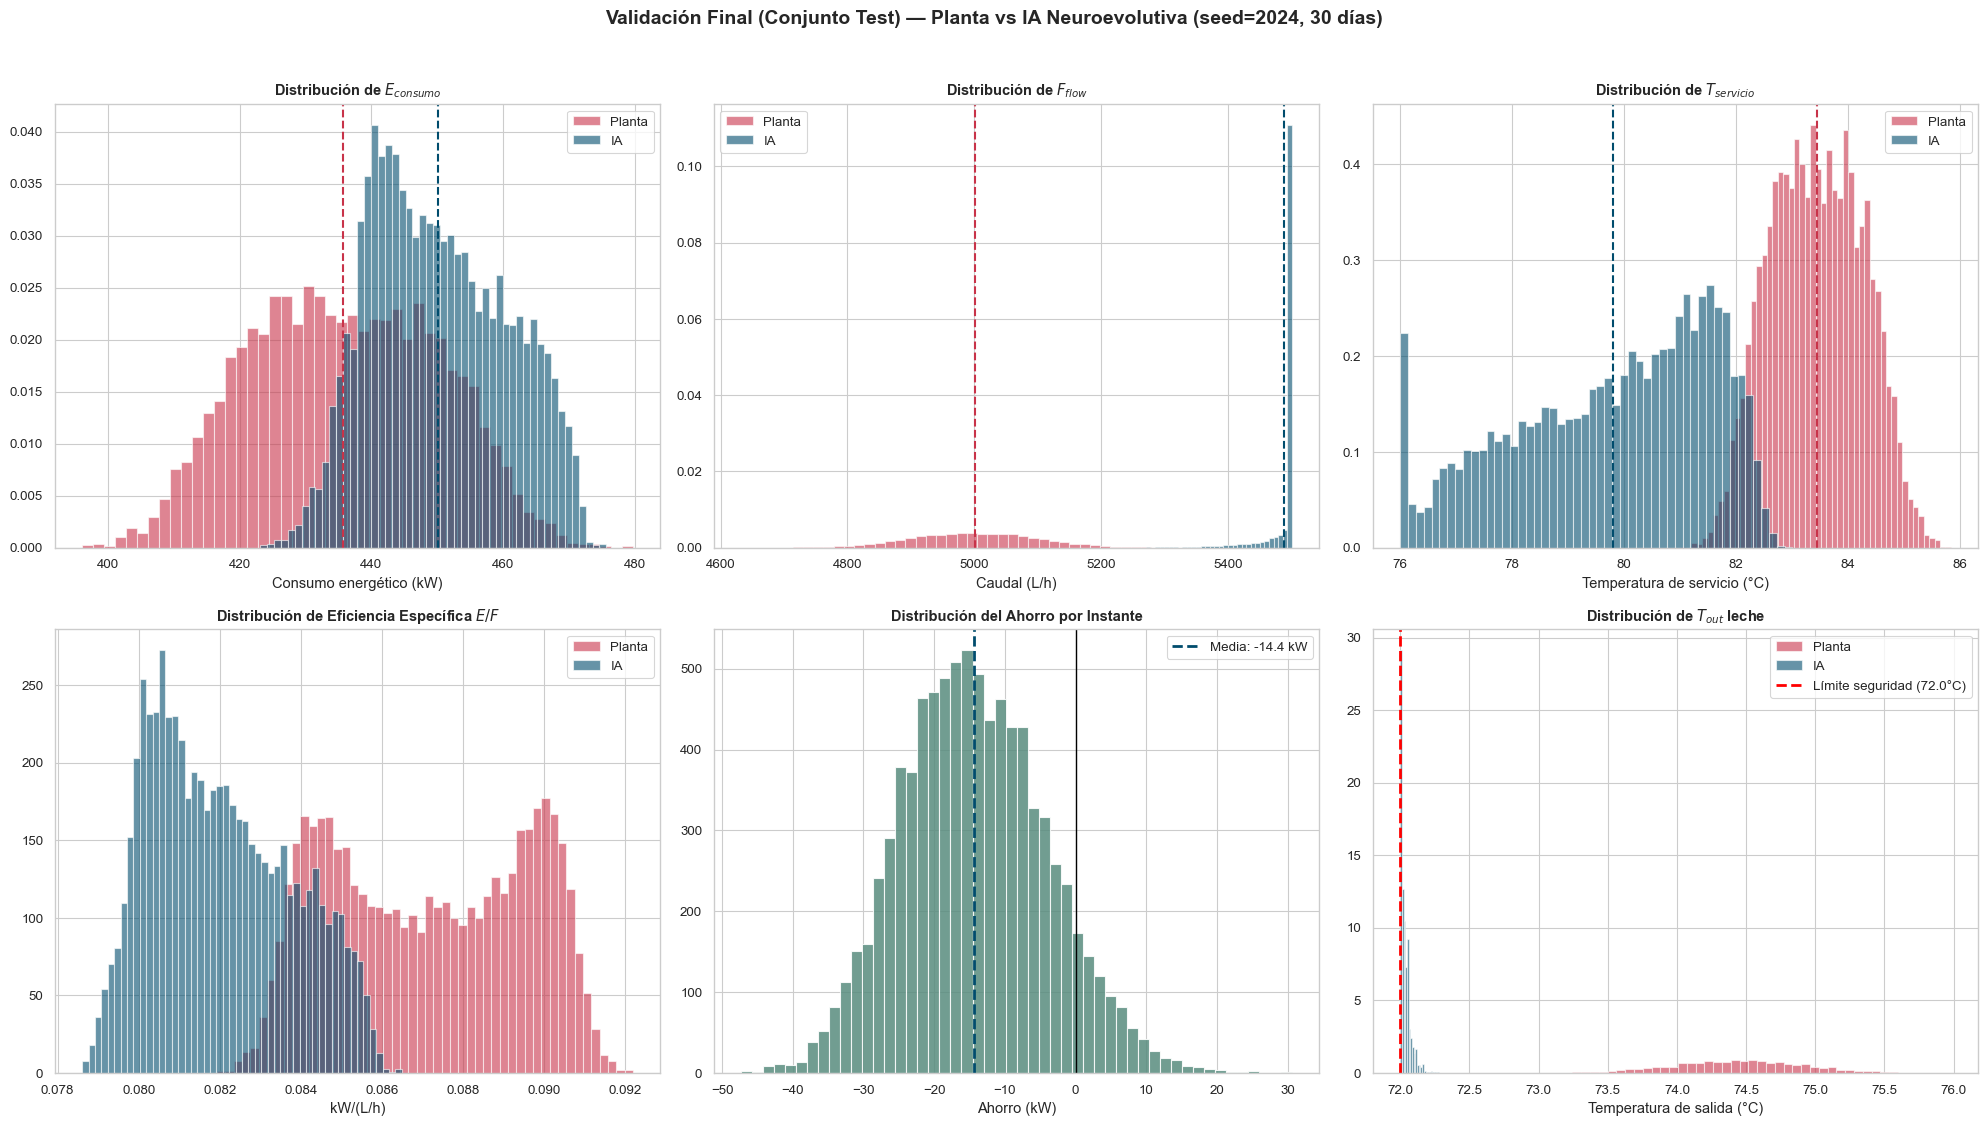

In [6]:
# ==============================================================================
# 6.1 DISTRIBUCIONES COMPARATIVAS: Planta vs IA
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# --- 6.1.1 Consumo energético ---
axes[0, 0].hist(df_eval["HIST_E_consumo"], bins=50, alpha=0.6, color="#c83349", label="Planta", density=True)
axes[0, 0].hist(df_eval["IA_E_consumo"], bins=50, alpha=0.6, color="#004c6d", label="IA", density=True)
axes[0, 0].axvline(E_hist_media, color="#c83349", linestyle="--", linewidth=1.5)
axes[0, 0].axvline(E_ia_media, color="#004c6d", linestyle="--", linewidth=1.5)
axes[0, 0].set_title("Distribución de $E_{consumo}$", fontweight="bold")
axes[0, 0].set_xlabel("Consumo energético (kW)")
axes[0, 0].legend()

# --- 6.1.2 Caudal (Producción) ---
axes[0, 1].hist(df_eval["HIST_F_flow"], bins=50, alpha=0.6, color="#c83349", label="Planta", density=True)
axes[0, 1].hist(df_eval["IA_F_flow"], bins=50, alpha=0.6, color="#004c6d", label="IA", density=True)
axes[0, 1].axvline(F_hist_media, color="#c83349", linestyle="--", linewidth=1.5)
axes[0, 1].axvline(F_ia_media, color="#004c6d", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Distribución de $F_{flow}$", fontweight="bold")
axes[0, 1].set_xlabel("Caudal (L/h)")
axes[0, 1].legend()

# --- 6.1.3 Temperatura de servicio ---
axes[0, 2].hist(df_eval["HIST_T_servicio"], bins=50, alpha=0.6, color="#c83349", label="Planta", density=True)
axes[0, 2].hist(df_eval["IA_T_servicio"], bins=50, alpha=0.6, color="#004c6d", label="IA", density=True)
axes[0, 2].axvline(T_serv_hist_media, color="#c83349", linestyle="--", linewidth=1.5)
axes[0, 2].axvline(T_serv_ia_media, color="#004c6d", linestyle="--", linewidth=1.5)
axes[0, 2].set_title("Distribución de $T_{servicio}$", fontweight="bold")
axes[0, 2].set_xlabel("Temperatura de servicio (°C)")
axes[0, 2].legend()

# --- 6.1.4 Eficiencia específica ---
axes[1, 0].hist(df_eval["HIST_Eficiencia"], bins=50, alpha=0.6, color="#c83349", label="Planta", density=True)
axes[1, 0].hist(df_eval["IA_Eficiencia"], bins=50, alpha=0.6, color="#004c6d", label="IA", density=True)
axes[1, 0].set_title("Distribución de Eficiencia Específica $E/F$", fontweight="bold")
axes[1, 0].set_xlabel("kW/(L/h)")
axes[1, 0].legend()

# --- 6.1.5 Distribución del ahorro (kW) ---
axes[1, 1].hist(df_eval["Ahorro_kW"], bins=50, color="#588c7e", edgecolor="white", alpha=0.85)
axes[1, 1].axvline(0, color="black", linestyle="-", linewidth=1)
axes[1, 1].axvline(ahorro_medio_kw, color="#004c6d", linestyle="--", linewidth=2,
                   label=f"Media: {ahorro_medio_kw:.1f} kW")
axes[1, 1].set_title("Distribución del Ahorro por Instante", fontweight="bold")
axes[1, 1].set_xlabel("Ahorro (kW)")
axes[1, 1].legend()

# --- 6.1.6 T_out: Planta vs IA ---
axes[1, 2].hist(df_eval["HIST_T_out"], bins=50, alpha=0.6, color="#c83349", label="Planta", density=True)
axes[1, 2].hist(df_eval["IA_T_out"], bins=50, alpha=0.6, color="#004c6d", label="IA", density=True)
axes[1, 2].axvline(T_OUT_MIN, color="red", linestyle="--", linewidth=2, label=f"Límite seguridad ({T_OUT_MIN}°C)")
axes[1, 2].set_title("Distribución de $T_{out}$ leche", fontweight="bold")
axes[1, 2].set_xlabel("Temperatura de salida (°C)")
axes[1, 2].legend()

plt.suptitle(f"Validación Final (Conjunto Test) — Planta vs IA Neuroevolutiva (seed={VALIDATION_SEED}, {VALIDATION_DAYS} días)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(str(IMAGES_DIR / "final_test_distribuciones.png"), dpi=300, bbox_inches="tight")
plt.show()

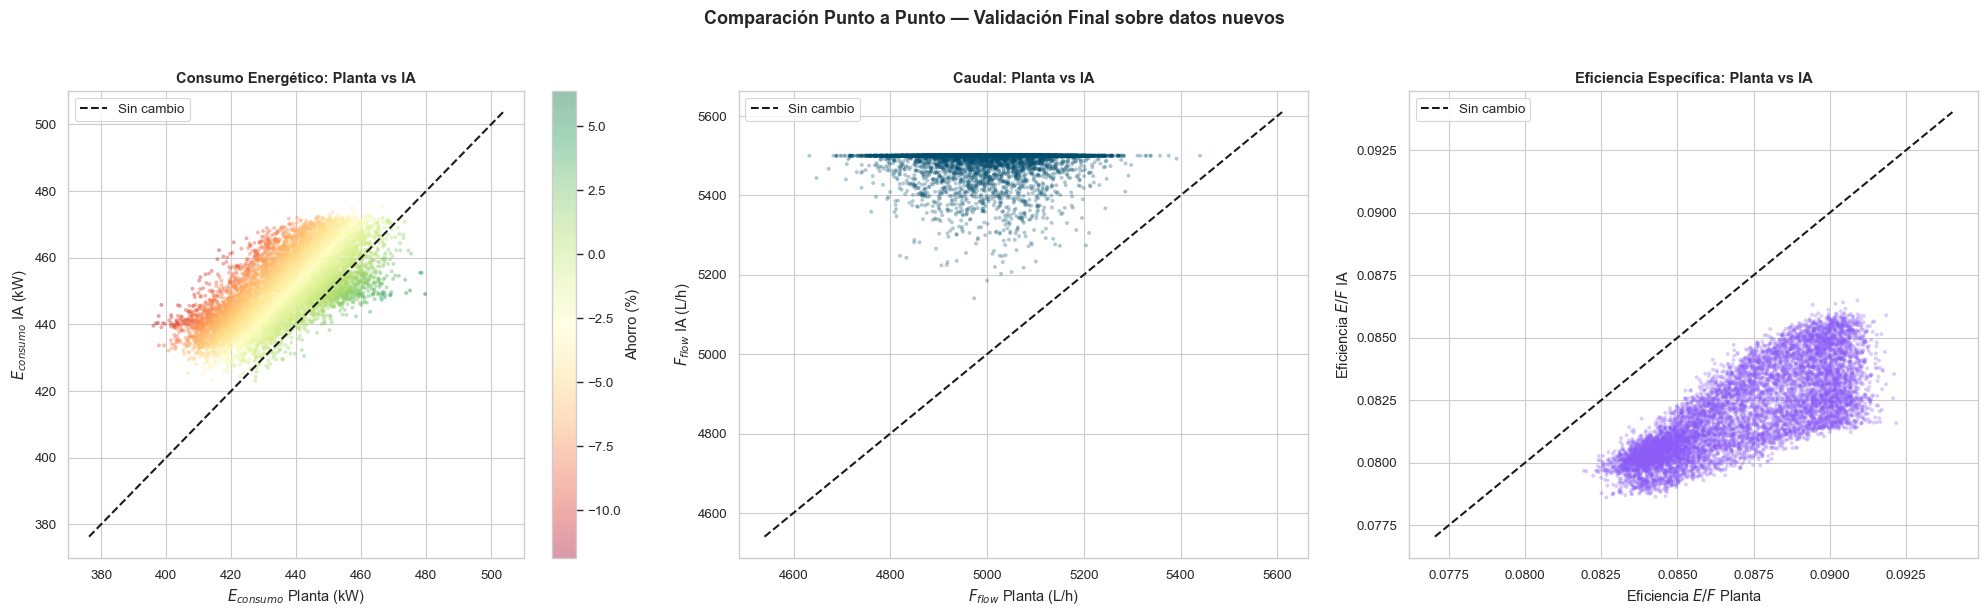

In [7]:
# ==============================================================================
# 6.2 SCATTER: Planta vs IA punto a punto
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 6.2.1 E_consumo ---
max_e = max(df_eval["HIST_E_consumo"].max(), df_eval["IA_E_consumo"].max()) * 1.05
min_e = min(df_eval["HIST_E_consumo"].min(), df_eval["IA_E_consumo"].min()) * 0.95

scatter = axes[0].scatter(df_eval["HIST_E_consumo"], df_eval["IA_E_consumo"],
                          c=df_eval["Ahorro_pct"], cmap="RdYlGn", alpha=0.4, s=8, edgecolors="none")
axes[0].plot([min_e, max_e], [min_e, max_e], "k--", linewidth=1.5, label="Sin cambio")
axes[0].set_xlabel("$E_{consumo}$ Planta (kW)")
axes[0].set_ylabel("$E_{consumo}$ IA (kW)")
axes[0].set_title("Consumo Energético: Planta vs IA", fontweight="bold")
axes[0].legend()
plt.colorbar(scatter, ax=axes[0], label="Ahorro (%)")

# --- 6.2.2 F_flow ---
max_f = max(df_eval["HIST_F_flow"].max(), df_eval["IA_F_flow"].max()) * 1.02
min_f = min(df_eval["HIST_F_flow"].min(), df_eval["IA_F_flow"].min()) * 0.98

axes[1].scatter(df_eval["HIST_F_flow"], df_eval["IA_F_flow"],
                c="#004c6d", alpha=0.3, s=8, edgecolors="none")
axes[1].plot([min_f, max_f], [min_f, max_f], "k--", linewidth=1.5, label="Sin cambio")
axes[1].set_xlabel("$F_{flow}$ Planta (L/h)")
axes[1].set_ylabel("$F_{flow}$ IA (L/h)")
axes[1].set_title("Caudal: Planta vs IA", fontweight="bold")
axes[1].legend()

# --- 6.2.3 Eficiencia específica ---
max_eff = max(df_eval["HIST_Eficiencia"].max(), df_eval["IA_Eficiencia"].max()) * 1.02
min_eff = min(df_eval["HIST_Eficiencia"].min(), df_eval["IA_Eficiencia"].min()) * 0.98

axes[2].scatter(df_eval["HIST_Eficiencia"], df_eval["IA_Eficiencia"],
                c="#8B5CF6", alpha=0.3, s=8, edgecolors="none")
axes[2].plot([min_eff, max_eff], [min_eff, max_eff], "k--", linewidth=1.5, label="Sin cambio")
axes[2].set_xlabel("Eficiencia $E/F$ Planta")
axes[2].set_ylabel("Eficiencia $E/F$ IA")
axes[2].set_title("Eficiencia Específica: Planta vs IA", fontweight="bold")
axes[2].legend()

plt.suptitle("Comparación Punto a Punto — Validación Final sobre datos nuevos",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(str(IMAGES_DIR / "final_test_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

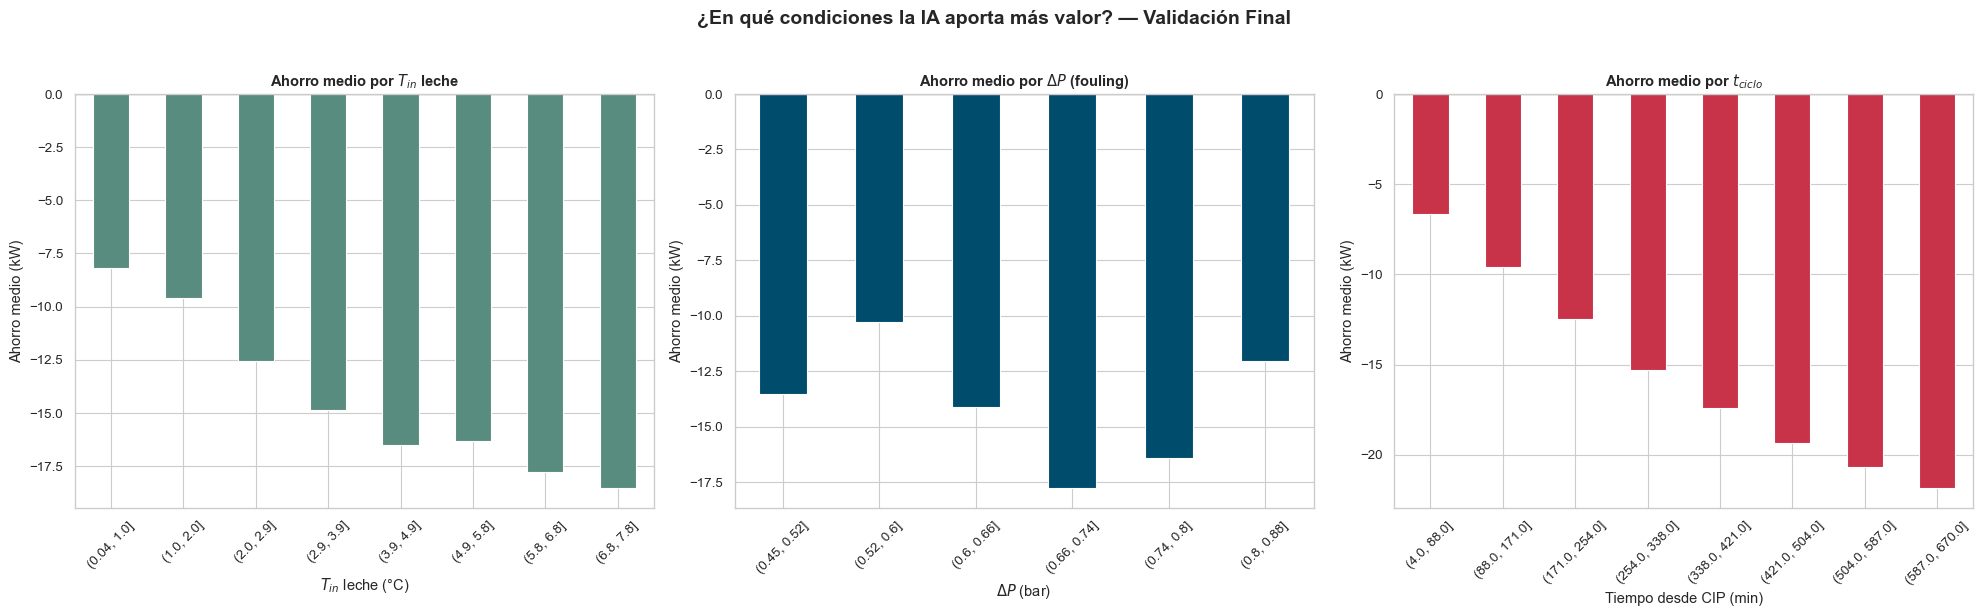

In [8]:
# ==============================================================================
# 6.3 AHORRO SEGMENTADO POR CONDICIONES OPERATIVAS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 6.3.1 Ahorro medio por rango de T_in_leche ---
df_eval["T_in_bin"] = pd.cut(df_eval["T_in_leche"], bins=8, precision=1)
ahorro_por_tin = df_eval.groupby("T_in_bin", observed=True)["Ahorro_kW"].mean()
ahorro_por_tin.plot(kind="bar", ax=axes[0], color="#588c7e", edgecolor="white")
axes[0].set_title("Ahorro medio por $T_{in}$ leche", fontweight="bold")
axes[0].set_xlabel("$T_{in}$ leche (°C)")
axes[0].set_ylabel("Ahorro medio (kW)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(0, color="black", linewidth=0.8)

# --- 6.3.2 Ahorro medio por Delta_P ---
df_eval["DP_bin"] = pd.cut(df_eval["Delta_P"], bins=6, precision=2)
ahorro_por_dp = df_eval.groupby("DP_bin", observed=True)["Ahorro_kW"].mean()
ahorro_por_dp.plot(kind="bar", ax=axes[1], color="#004c6d", edgecolor="white")
axes[1].set_title(r"Ahorro medio por $\Delta P$ (fouling)", fontweight="bold")
axes[1].set_xlabel(r"$\Delta P$ (bar)")
axes[1].set_ylabel("Ahorro medio (kW)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(0, color="black", linewidth=0.8)

# --- 6.3.3 Ahorro medio por t_ciclo ---
df_eval["t_ciclo_bin"] = pd.cut(df_eval["t_ciclo"], bins=8, precision=0)
ahorro_por_tciclo = df_eval.groupby("t_ciclo_bin", observed=True)["Ahorro_kW"].mean()
ahorro_por_tciclo.plot(kind="bar", ax=axes[2], color="#c83349", edgecolor="white")
axes[2].set_title("Ahorro medio por $t_{ciclo}$", fontweight="bold")
axes[2].set_xlabel("Tiempo desde CIP (min)")
axes[2].set_ylabel("Ahorro medio (kW)")
axes[2].tick_params(axis="x", rotation=45)
axes[2].axhline(0, color="black", linewidth=0.8)

plt.suptitle("¿En qué condiciones la IA aporta más valor? — Validación Final",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(str(IMAGES_DIR / "final_test_ahorro_segmentado.png"), dpi=300, bbox_inches="tight")
plt.show()

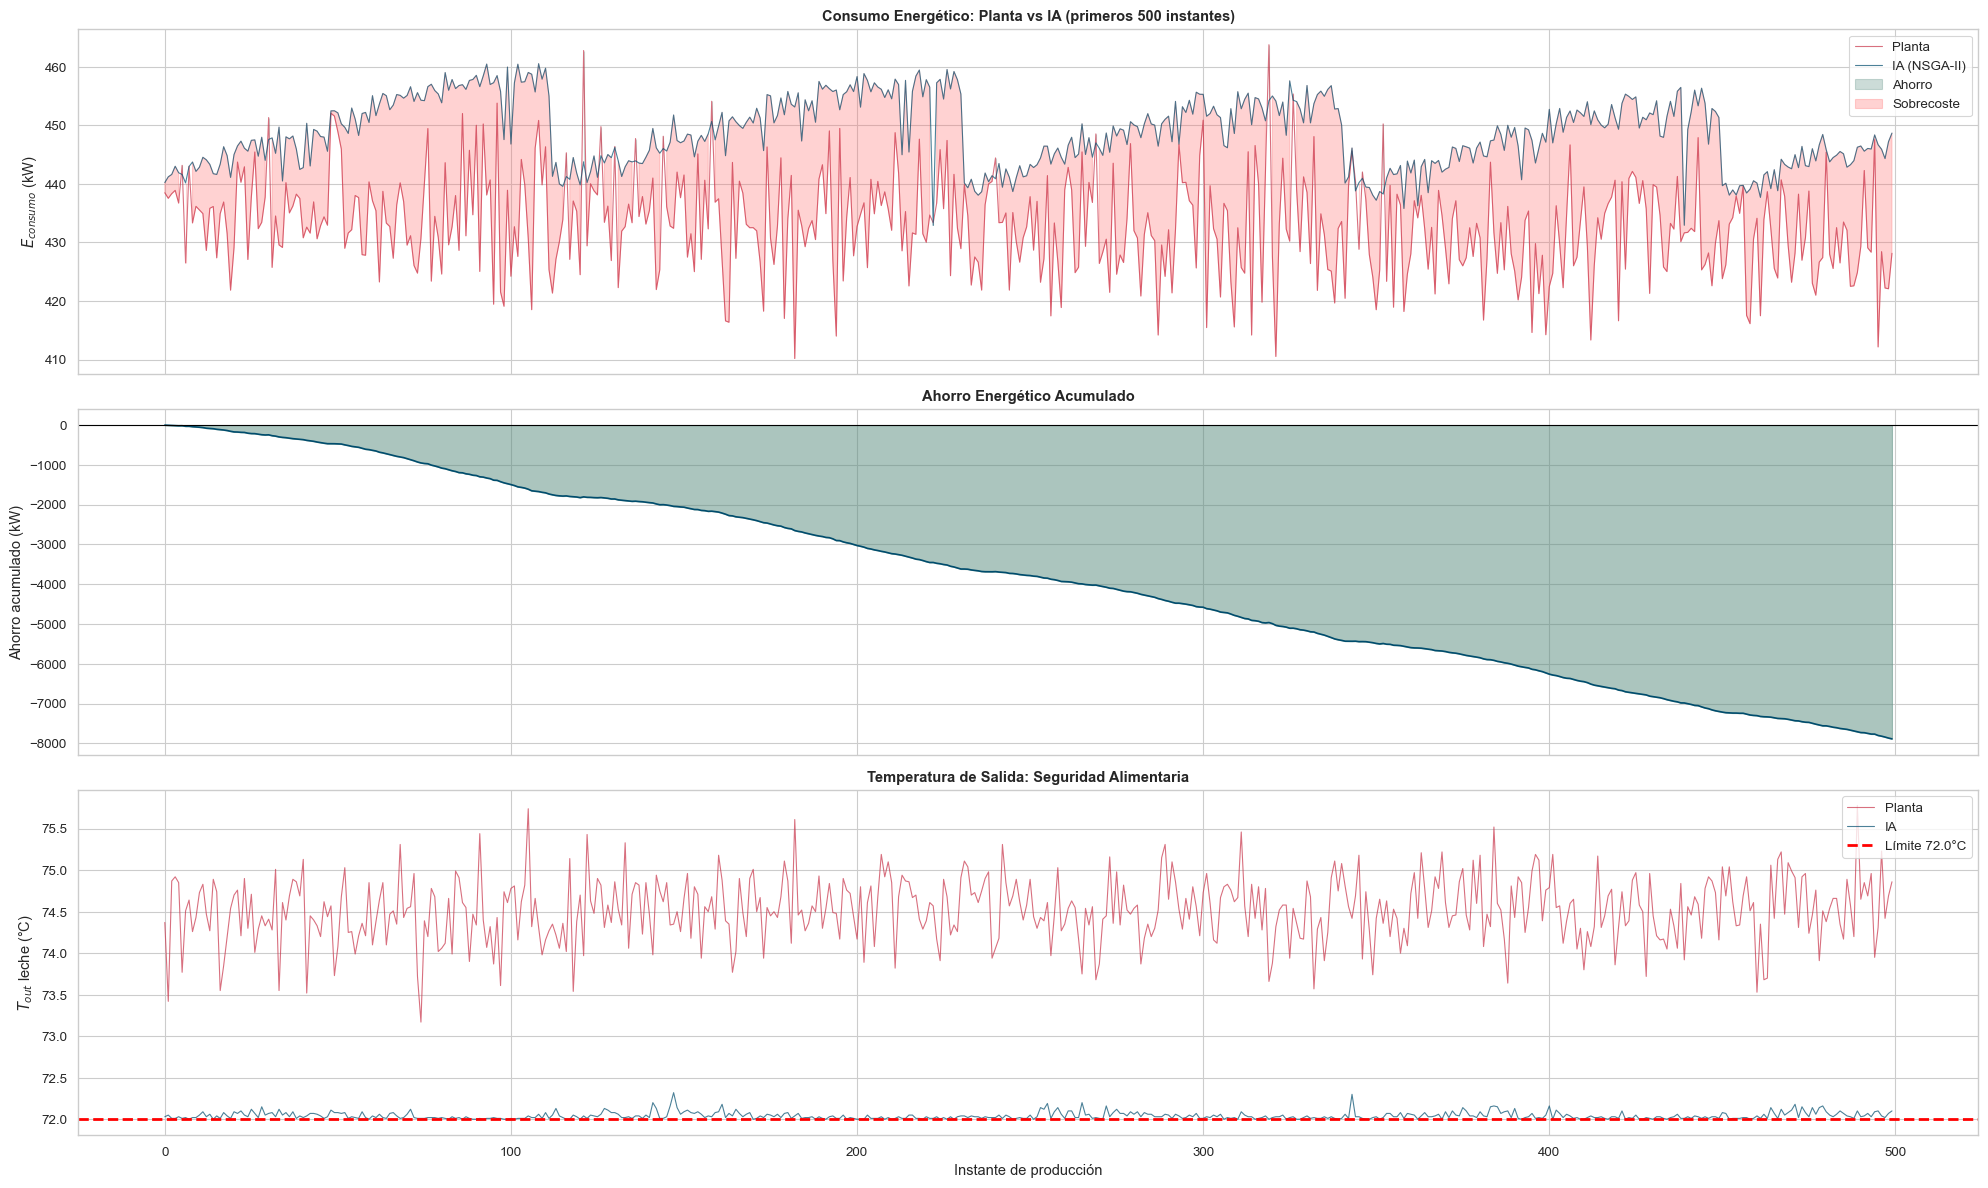

In [9]:
# ==============================================================================
# 6.4 SIMULACIÓN TEMPORAL: Consumo a lo largo de la operación
# ==============================================================================
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

N_PLOT = min(500, len(df_eval))
x = range(N_PLOT)

# --- 6.4.1 Consumo energético en el tiempo ---
axes[0].plot(x, df_eval["HIST_E_consumo"].iloc[:N_PLOT], color="#c83349", alpha=0.7,
             linewidth=0.8, label="Planta")
axes[0].plot(x, df_eval["IA_E_consumo"].iloc[:N_PLOT], color="#004c6d", alpha=0.7,
             linewidth=0.8, label="IA (NSGA-II)")
axes[0].fill_between(x, df_eval["IA_E_consumo"].iloc[:N_PLOT], df_eval["HIST_E_consumo"].iloc[:N_PLOT],
                     where=df_eval["Ahorro_kW"].iloc[:N_PLOT] > 0, alpha=0.3, color="#588c7e", label="Ahorro")
axes[0].fill_between(x, df_eval["IA_E_consumo"].iloc[:N_PLOT], df_eval["HIST_E_consumo"].iloc[:N_PLOT],
                     where=df_eval["Ahorro_kW"].iloc[:N_PLOT] <= 0, alpha=0.3, color="#ff6b6b", label="Sobrecoste")
axes[0].set_ylabel("$E_{consumo}$ (kW)")
axes[0].set_title(f"Consumo Energético: Planta vs IA (primeros {N_PLOT} instantes)", fontweight="bold")
axes[0].legend(loc="upper right")

# --- 6.4.2 Ahorro acumulado ---
ahorro_acum = df_eval["Ahorro_kW"].iloc[:N_PLOT].cumsum()
axes[1].fill_between(x, ahorro_acum, alpha=0.5, color="#588c7e")
axes[1].plot(x, ahorro_acum, color="#004c6d", linewidth=1.2)
axes[1].set_ylabel("Ahorro acumulado (kW)")
axes[1].set_title("Ahorro Energético Acumulado", fontweight="bold")
axes[1].axhline(0, color="black", linewidth=0.8)

# --- 6.4.3 T_out comparativa ---
axes[2].plot(x, df_eval["HIST_T_out"].iloc[:N_PLOT], color="#c83349", alpha=0.7,
             linewidth=0.8, label="Planta")
axes[2].plot(x, df_eval["IA_T_out"].iloc[:N_PLOT], color="#004c6d", alpha=0.7,
             linewidth=0.8, label="IA")
axes[2].axhline(T_OUT_MIN, color="red", linestyle="--", linewidth=2, label=f"Límite {T_OUT_MIN}°C")
axes[2].set_ylabel("$T_{out}$ leche (°C)")
axes[2].set_xlabel("Instante de producción")
axes[2].set_title("Temperatura de Salida: Seguridad Alimentaria", fontweight="bold")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.savefig(str(IMAGES_DIR / "final_test_simulacion_temporal.png"), dpi=300, bbox_inches="tight")
plt.show()